In [19]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

In [24]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


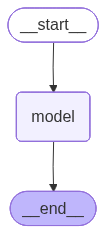

In [28]:
from langchain.agents import create_agent

# without any tools
agent1=create_agent(
    model=llm,
    tools=[],
    system_prompt="You are a helpfull assistant."
)
agent1

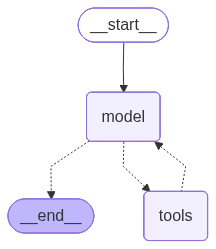

In [31]:
def get_weather(city: str) -> str:
    """Get the weather for a city."""   # This is the doc string which LLM checks to call the correct tool 
    return f"weather in the {city} is sunny."

agent2=create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpfull assistant."
)
agent2

In [35]:
# run the agent
response = agent2.invoke({"messages":[{"role":"user","content":"What is the weather like in Hyderabad"}]}) 
response

{'messages': [HumanMessage(content='What is the weather like in Hyderabad', additional_kwargs={}, response_metadata={}, id='a372a5df-5d24-4258-bcc9-a095bd8c7b9a'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "Hyderabad"}'}, '__gemini_function_call_thought_signatures__': {'1b92e19a-409a-4261-aaa1-dfddc4357837': 'Co0CARFNMg/QTdOLJBeeXWSu0HIjxTNc8SIZh1Z121ONgwutl6Hp+4169GEK08+Z9IPxzJ7GwhtC2GY1csxHgmoR+dQaWnIxTSsB/RuGsy9zrAhWu9ozEWz3P5uwjQt6QfYLCQPNBXKoEwdccOrApaQpqdAAZv7fWgI1d9/yLBp5HaPvVDA4s58XlZCkX2jWthqiN9J019ThkvhL+UEMtF7yb36QfNw1jcy2torbXCinDMtDdlaXuXu288vGXAO1LlY2xe5Fr9d/TJIjGVhwMDqhgH1n3EBMuQ/QOggMpralYuyDNB3q1vDcpWp8qfxOotSpU4BNUuTGk2YR5Pxm8VbeSdkXYIjVRz0lmDOzAIY='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f322d-d679-7cb3-8eee-01b483219f42-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Hyderabad'}, 

In [40]:
response['messages'][-1].content

'The weather in Hyderabad is sunny.'